# Test: Moving Coastlines Implementation


In [84]:
import sys
import os

# Insert the local project root ahead of any installed version.
_project_root = os.path.abspath("..")
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

# Evict any already-cached pyslfp modules (e.g. the installed pip version)
# so the next import picks up the local source instead.
for _key in list(sys.modules.keys()):
    if _key.startswith("pyslfp"):
        del sys.modules[_key]

import numpy as np
import matplotlib.pyplot as plt
import pyslfp as sl
from pyslfp.finger_print_moving_coastlines import FingerPrint

print(f"Loaded pyslfp from: {sl.__file__}")

Loaded pyslfp from: /space/dah94/pyslfp/pyslfp/pyslfp/__init__.py


## Setup

In [85]:
fp = FingerPrint(lmax=256)
fp.set_state_from_ice_ng(version=sl.IceModel.ICE7G, date=0.0)


In [86]:
direct_load = fp.northern_hemisphere_load(fraction=10)

## Solve: static vs moving coastline

In [87]:
sl_change_static, _, _, _ = fp(
    direct_load=direct_load,
    verbose=True,
)

Iteration = 1, relative error = 2.1312e-02
Iteration = 2, relative error = 9.5109e-04
Iteration = 3, relative error = 1.1524e-04
Iteration = 4, relative error = 1.9042e-05
Iteration = 5, relative error = 3.6648e-06
Iteration = 6, relative error = 7.6841e-07


In [88]:
sl_change_moving, _, _, _ = fp(
    direct_load=direct_load,
    moving_coastline=True,
    verbose=True,
)

Iteration = 1, relative error = 5.1610e-02
Iteration = 2, relative error = 3.9956e-02
Iteration = 3, relative error = 3.9736e-02
Iteration = 4, relative error = 2.6898e-05
Iteration = 5, relative error = 3.5816e-06
Iteration = 6, relative error = 7.5671e-07


In [ ]:
# Background ocean function
ocean_func_background = fp.ocean_function

# Updated ocean function based on sea level after moving coastline solve
absolute_sl_after = fp.sea_level + sl_change_moving
ocean_func_updated = fp._return_ocean_function_from_sea_level(absolute_sl_after)

# Difference: +1 = newly flooded, -1 = newly exposed
ocean_func_diff = SHGrid.from_array(
    ocean_func_updated.data - ocean_func_background.data,
    grid=fp.grid,
)

## Sea level fingerprint comparison

Text(0.5, 1.05, 'Static coastline')

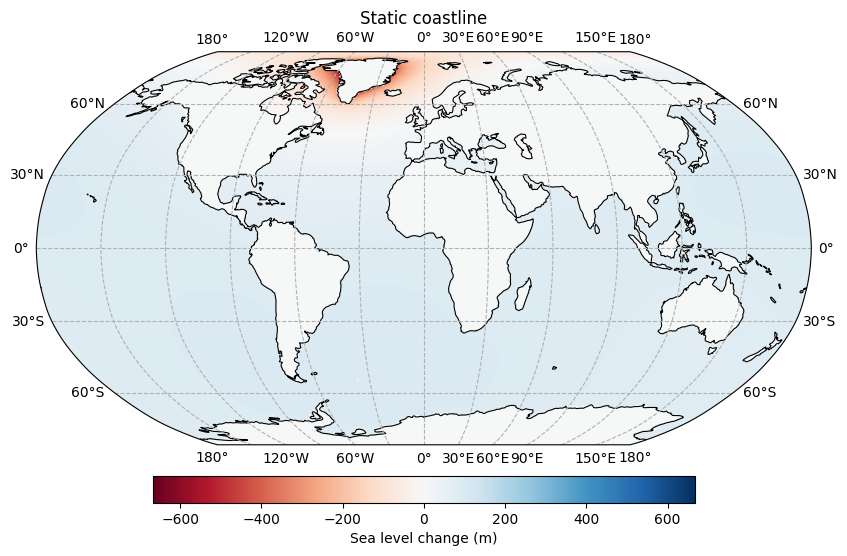

In [100]:
# Ocean masks for plotting
ocean_mask_background = fp.ocean_projection()

fig, ax, im = sl.plot(
    sl_change_static * ocean_func_background,
    coasts=True,
    colorbar_label="Sea level change (m)",
    symmetric=True,
)
ax.set_title("Static coastline", y=1.05)

Text(0.5, 1.05, 'Moving coastline')

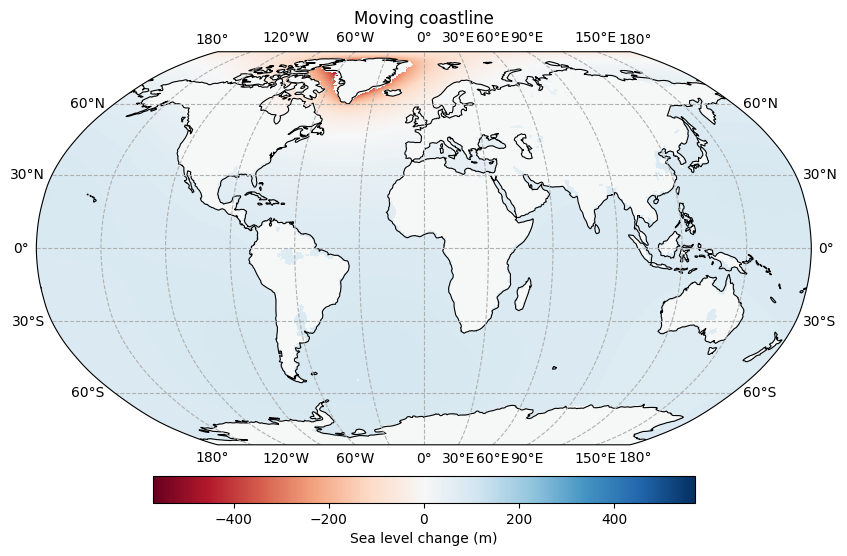

In [102]:
fig, ax, im = sl.plot(
    sl_change_moving * ocean_func_updated,
    coasts=True,
    colorbar_label="Sea level change (m)",
    symmetric=True,
)
ax.set_title("Moving coastline", y=1.05)

Text(0.5, 1.05, 'Sea level difference: moving $-$ static')

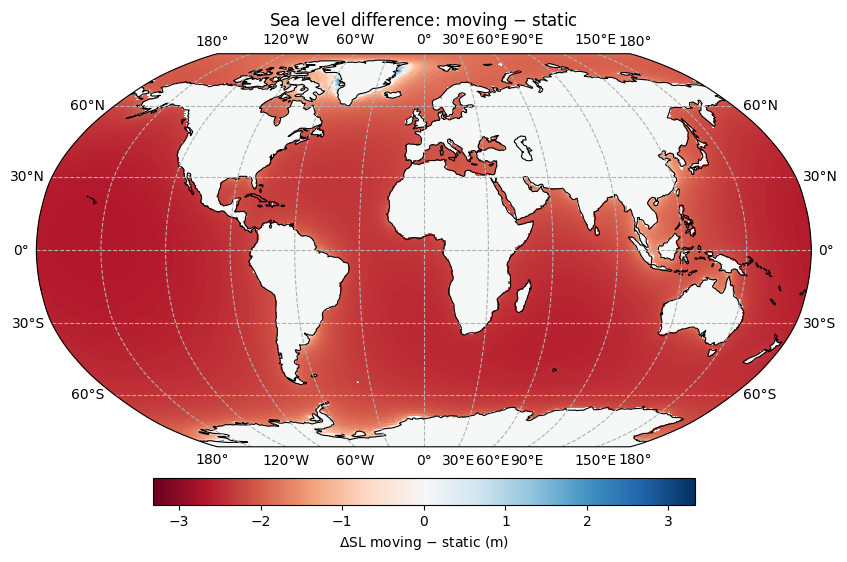

In [103]:
# Difference: moving minus static
from pyshtools import SHGrid

sl_diff = SHGrid.from_array(
    sl_change_moving.data - sl_change_static.data,
    grid=fp.grid,
)

fig, ax, im = sl.plot(
    sl_diff * ocean_func_background,
    coasts=True,
    colorbar_label="$\\Delta$SL moving $-$ static (m)",
    symmetric=True,
)
ax.set_title("Sea level difference: moving $-$ static", y=1.05)

## Ocean function comparison

Text(0.5, 1.05, 'Ocean function change $C - C_0$\n($+1$ = newly flooded, $-1$ = newly exposed)')

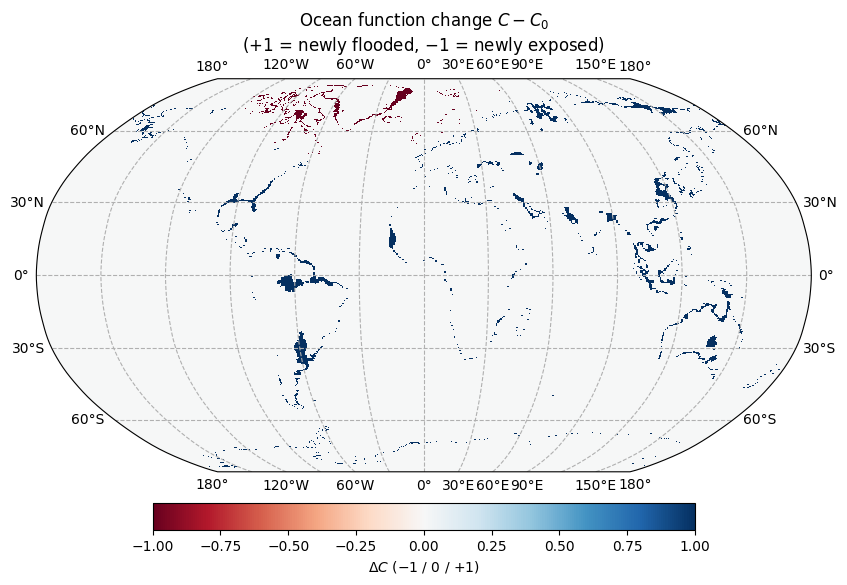

In [93]:
fig, ax, im = sl.plot(
    ocean_func_diff,
    coasts=False,
    colorbar_label="$\\Delta C$ ($-1$ / $0$ / $+1$)",
    cmap="RdBu",
    vmax=1,
    vmin=-1,
)
ax.set_title("Ocean function change $C - C_0$\n($+1$ = newly flooded, $-1$ = newly exposed)", y=1.05)


## Ocean area and global statistics

In [94]:
area_background = fp.ocean_area
area_updated = fp.integrate(ocean_func_updated)
area_diff = area_updated - area_background
area_diff_pct = 100.0 * area_diff / area_background

print(f"Background ocean area : {area_background:.6e} m^2")
print(f"Updated ocean area    : {area_updated:.6e} m^2")
print(f"Absolute difference   : {area_diff:+.6e} m^2")
print(f"Relative difference   : {area_diff_pct:+.4e} %")

Background ocean area : 3.634105e+14 m^2
Updated ocean area    : 3.713212e+14 m^2
Absolute difference   : +7.910654e+12 m^2
Relative difference   : +2.1768e+00 %


In [104]:
# Ocean-averaged sea level change (should equal eustatic mean)
mean_static = fp.ocean_average(sl_change_static)
mean_moving = fp.integrate(ocean_func_updated * sl_change_moving) / area_updated

# Number of cells that changed
n_flooded  = int(np.sum(ocean_func_diff.data >  0.5))
n_exposed  = int(np.sum(ocean_func_diff.data < -0.5))

print(f"{'':35s} {'Static':>12s} {'Moving':>12s}")
print(f"{'Max SL change (m)':35s} {np.max(sl_change_static.data):12.4f} {np.max(sl_change_moving.data):12.4f}")
print(f"{'Min SL change (m)':35s} {np.min(sl_change_static.data):12.4f} {np.min(sl_change_moving.data):12.4f}")
print(f"{'Ocean-mean SL change (m)':35s} {mean_static:12.6f} {mean_moving:12.6f}")

                                          Static       Moving
Max SL change (m)                       103.2871     100.9317
Min SL change (m)                     -1343.1113   -1344.3246
Ocean-mean SL change (m)               77.458251    75.808075
